In [1]:
"""
Author: Song Yang
Date: 20250608
Version: 0.2.3
"""

import numpy as np
from openmmtools.multistate import MultiStateReporter, ReplicaExchangeAnalyzer
from openmm import unit
import pymbar
from pymbar import timeseries
import pickle
import os
from typing import Dict, List, Tuple, Optional, Union

# Constants
kB = (unit.MOLAR_GAS_CONSTANT_R).value_in_unit(unit.kilojoule / (unit.kelvin * unit.mole))

class FESAnalyzer:
    def __init__(self, output_file: str, cv_file: str, interval: int=1):
        """
        Initialize the FES analyzer with simulation data files.
        
        Parameters:
        - output_file: Path to simulation output file
        - cv_file: Path to collective variable (CV) data file
        - interval: Interval for getting CV data compared to energies (default: 1)
        """
        self.output_file = output_file
        self.cv_file = cv_file
        self.fes = None
        self.interval = interval
        self._validate_files()
        self._load_simulation_data()
        
    def _validate_files(self) -> None:
        """Validate that input files exist."""
        if not os.path.exists(self.output_file):
            raise FileNotFoundError(f"Output file not found: {self.output_file}")
        if not os.path.exists(self.cv_file):
            raise FileNotFoundError(f"CV file not found: {self.cv_file}")
        
    def _load_simulation_data(self) -> None:
        """Load basic simulation data from files."""
        try:
            # Load reporter and analyzer
            reporter = MultiStateReporter(self.output_file, open_mode="r")
            analyzer = ReplicaExchangeAnalyzer(reporter)
            
            # Read simulation data
            states, _ = reporter.read_thermodynamic_states()
            temperature_list = [s.temperature for s in states]
            
            # Read energies and states
            self.replica_energies, self.unsampled_energies, _, self.replica_state_indices = analyzer.read_energies()
            self.replica_energies = self.replica_energies[:, :, ::self.interval]
            self.unsampled_energies = self.unsampled_energies[:, :, ::self.interval]
            
            reporter.close()
            
            # Verify number of replicas matches number of states
            n_replicas = self.replica_energies.shape[0]
            n_states = len(states)
            if n_replicas != n_states:
                raise ValueError(f"Number of replicas ({n_replicas}) does not match number of states ({n_states})")
            
            # Process temperature data
            self.n_states = n_states
            self.temperatures_k = np.array([temp.value_in_unit(unit.kelvin) for temp in temperature_list])
            self.beta_k = 1 / (kB * self.temperatures_k)
            
            # Load CV data more efficiently
            cv_data = np.loadtxt(self.cv_file)
            if cv_data.shape[1] != n_states + 1:
                raise ValueError(f"CV data has wrong shape. Expected {n_states+1} columns, got {cv_data.shape[1]}")
            self.cv_values_replica = cv_data[:, 1:].T  # Transpose to get (n_states, n_frames)
            
        except Exception as e:
            raise RuntimeError(f"Error loading simulation data: {str(e)}")
    

    def _get_subsampled_indices(self, g: float = 1.0, length_ratio: float = 1.0, 
                               start_point: Optional[int] = None, start_ratio: Optional[float] = None) -> np.ndarray:
        """Determine subsampled indices based on analysis parameters."""
        total_frames = self.replica_energies.shape[2]
        
        # Determine start index
        if start_ratio is not None:
            start_idx = int(total_frames * start_ratio)
        elif start_point is not None:
            start_idx = start_point
        else:
            start_idx = 0
            
        # Determine end index
        n_frames = int((total_frames - start_idx) * length_ratio)
        end_idx = start_idx + n_frames
        
        if end_idx <= start_idx:
            raise ValueError("Invalid frame selection: end index <= start index")
            
        # Subsample to remove correlation
        subsampled = timeseries.subsample_correlated_data(
            self.cv_values_replica[0, start_idx:end_idx], g=g
        )
        self.subsampled_indices = [x + start_idx for x in subsampled]
    
    def initialize_fes(self, g: float = 1.0, length_ratio: float = 1.0, 
                      start_point: Optional[int] = None, start_ratio: Optional[float] = None) -> None:
        """Calculate free energy surface (FES) using MBAR.

        Parameters:
        - g: Statistical inefficiency value
        - length_ratio: Fraction of trajectory length to use
        - start_point: Starting frame index
        - start_ratio: Fraction of trajectory to skip at beginning
        """
        # Get subsampled indices
        self._get_subsampled_indices(
            g=g, length_ratio=length_ratio, 
            start_point=start_point, start_ratio=start_ratio
        )
        
        # Prepare energy and CV arrays
        u_kln = self.replica_energies[:, :, self.subsampled_indices]
        cv_kn = self.cv_values_replica[:, self.subsampled_indices]
        u_kn = pymbar.utils.kln_to_kn(u_kln) # This function has some misleading documentation. In actually, it should be named lkn_to_kn (k: state, l: replica, n: frame)
        
        # Calculate FES
        n_states = len(self.subsampled_indices) * np.ones(self.n_states, dtype=int)
        self.fes = pymbar.FES(u_kn, n_states, mbar_options=dict(solver_protocol="robust"))
        self.u_kn = u_kn
        self.concatenated_cv = np.concatenate(cv_kn)
        self.subsampled_unsampled_energies = self.unsampled_energies[:, :, self.subsampled_indices]

    def analyze(self, u_n: np.ndarray, cv_n: np.ndarray, temperature: float, 
               n_bins: int = 100, ranges: Optional[List[float]] = None, left_bound: float = 3, right_bound: float = 6) -> Dict:
        """
        Analyze the free energy surface.
        
        Parameters:
        - u_n: Energy array
        - cv_n: Collective variable array
        - temperature: Temperature for analysis
        - n_bins: Number of bins for histogram
        - ranges: Range for CV values
        
        Returns:
        Dictionary with analysis results
        """
        if self.fes is None:
            raise RuntimeError('FES not initialized. Call initialize_fes() first.')
        
        # Determine bin ranges
        if ranges is None:
            padding = 0.05 * (cv_n.max() - cv_n.min())
            ranges = [cv_n.min() + padding, cv_n.max() - padding]
        
        # Bin the CV
        counts, bin_edges = np.histogram(cv_n, bins=n_bins, range=ranges)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

        # Calculate FES
        print('u_n:', u_n.shape)
        print('cv_n: ', cv_n.shape)
        print('bin_edges: ', bin_edges[0], bin_edges[-1], len(bin_edges))
        self.fes.generate_fes(u_n, cv_n, fes_type="histogram", 
                            histogram_parameters={"bin_edges": [bin_edges]})
        results = self.fes.get_fes(bin_centers, reference_point="from-lowest", 
                                 uncertainty_method="analytical")

        # Convert to kJ/mol
        beta = 1/(temperature * kB)
        pmf = results['f_i'] / beta
        pmf_uncertainty = results['df_i'] / beta
        
        # Calculate metrics
        metrics = self.calculate_metrics(bin_centers, pmf, temperature, left_bound, right_bound)
    
        return {
            "cv_values": bin_centers,
            "pmf": pmf,
            "pmf_uncertainty": pmf_uncertainty,
            "metrics": metrics
        }

    def analyze_onestate(self, selected_state: int = 0, **kwargs) -> Dict:
        """
        Perform FES analysis for a single thermodynamic state.
        
        Parameters:
        - selected_state: Index of thermodynamic state to analyze
        - **kwargs: Additional arguments to pass to analyze()
        
        Returns:
        Dictionary containing analysis results
        """
        if selected_state < 0 or selected_state >= self.n_states:
            raise ValueError(f"Invalid state index {selected_state}. Must be between 0 and {self.n_states-1}")
            
        return self.analyze(self.u_kn[selected_state, :], self.concatenated_cv, 
                          self.temperatures_k[selected_state], **kwargs)
    
    def analyze_one_mixing_parameters(self, mixing_parameters: Dict, temperature: float, method: str ='EXP', **kwargs) -> Dict:
        """
        Perform FES analysis for a single mixing parameter set.

        Parameters:
        - mixing_parameters: Dictionary of mixing parameters
        - temperature: Temperature for analysis
        - method: Method to use for mixing ('EXP' or 'HAM')
        - **kwargs: Additional arguments to pass to analyze()

        Returns:
        Dictionary containing analysis results
        """
        if method == 'EXP':
            beta, C1, C2 = mixing_parameters['beta'], mixing_parameters['C1'], mixing_parameters['C2']
            return self.analyze(self.EXPMixing_func(beta, C1, C2, temperature), self.concatenated_cv,
                            temperature, **kwargs)
        elif method == 'HAM':
            delta, C1, C2 = mixing_parameters['delta'], mixing_parameters['C1'], mixing_parameters['C2']
            return self.analyze(self.HAMMixing_func(delta, C1, C2, temperature), self.concatenated_cv,
                            temperature, **kwargs)
        else:
            raise ValueError(f"Invalid mixing method {method}. Must be 'EXP' or 'HAM'.")


    def EXPMixing_func(self, beta, C1, C2, temperature):
        E1 = np.concatenate(self.subsampled_unsampled_energies[:,0,:]) * (kB * temperature)
        E2 = np.concatenate(self.subsampled_unsampled_energies[:,1,:]) * (kB * temperature)

        # Avoid the large exp values
        E1_mean = E1.mean()
        E1 -= E1_mean
        E2 -= E1_mean

        term1 = np.exp(-beta * (E1 + C1))
        term2 = np.exp(-beta * (E2 + C2))

        E = - (1 / beta) * np.log(term1 + term2)
        E += E1_mean
        return E / (kB * temperature)

    def HAMMixing_func(self, delta, C1, C2, temperature):
        E1 = np.concatenate(self.subsampled_unsampled_energies[:,0,:]) * (kB * temperature)
        E2 = np.concatenate(self.subsampled_unsampled_energies[:,1,:]) * (kB * temperature)

        dV=C2-C1
        part1=(E1+E2+dV)/2
        part2=(E1-E2-dV)/2

        energy=part1-np.sqrt(part2**2+delta**2)
        return energy/(kB * temperature)

    def parameter_sweep(self, param_name: str, values: List, 
                        default_params: Optional[Dict] = None, **kwargs) -> Dict:
        """
        Perform a parameter sweep analysis.
        
        Parameters:
        - param_name: Name of parameter to vary ('g', 'length_ratio', etc.)
        - values: List of values to test for the parameter
        - default_params: Dictionary of default parameter values
        
        Returns:
        Dictionary mapping parameter values to analysis results
        """
        if default_params is None:
            default_params = {
                'g': 1,
                'length_ratio': 1,
                'start_point': None,
                'start_ratio': 0,
                'selected_state': 0
            }
        
        results = {}
        for value in values:
            params = default_params.copy()
            params[param_name] = value
            self.initialize_fes(g=params['g'], length_ratio=params['length_ratio'],
                                start_point=params['start_point'], start_ratio=params['start_ratio'])
            results[value] = self.analyze_onestate(selected_state=params['selected_state'], **kwargs)

            print(results[value]['metrics'])
            
        return results

    @staticmethod
    def save_results(results: Dict, filename: str) -> None:
        """Save analysis results to a file."""
        with open(filename, 'wb') as f:
            pickle.dump(results, f)

    @staticmethod
    def load_results(filename: str) -> Dict:
        """Load analysis results from a file."""
        with open(filename, 'rb') as f:
            return pickle.load(f)
        
    @staticmethod
    def calculate_barrier(cv_values: np.ndarray, pmf: np.ndarray, 
                         left_bound: float = 3, right_bound: float = 6) -> Tuple[float, float]:
        """Calculate barrier position and height within specified CV bounds.
        
        Parameters:
        - cv_values: Array of CV values
        - pmf: Potential of mean force values
        - left_bound: Left boundary for barrier search
        - right_bound: Right boundary for barrier search
        
        Returns:
        Tuple of (barrier_position, barrier_height)
        """
        mask = (cv_values > left_bound) & (cv_values < right_bound)
        if not np.any(mask):
            raise ValueError("No data points found within specified bounds")
            
        barrier_idx = np.argmax(pmf[mask])
        barrier_pos = cv_values[mask][barrier_idx]
        barrier_height = pmf[mask][barrier_idx]
        return barrier_pos, barrier_height
    
    @staticmethod
    def calculate_basins(cv_values: np.ndarray, pmf: np.ndarray, 
                         barrier_position: float) -> Tuple[float, float, float, float]:
        """Calculate basin positions and free energies relative to a barrier.
        
        Parameters:
        - cv_values: Array of CV values
        - pmf: Potential of mean force values
        - barrier_position: Position dividing the two basins
        
        Returns:
        Tuple of (basin1_pos, basin2_pos, basin1_pmf, basin2_pmf)
        """
        # Left basin (CV < barrier)
        left_basin = cv_values < barrier_position
        if not np.any(left_basin):
            raise ValueError("No data points found in left basin")
        basin1_idx = np.argmin(pmf[left_basin])
        basin1_pos = cv_values[left_basin][basin1_idx]
        basin1_pmf = pmf[left_basin][basin1_idx]

        # Right basin (CV > barrier)
        right_basin = cv_values > barrier_position
        if not np.any(right_basin):
            raise ValueError("No data points found in right basin")
        basin2_idx = np.argmin(pmf[right_basin])
        basin2_pos = cv_values[right_basin][basin2_idx]
        basin2_pmf = pmf[right_basin][basin2_idx]

        return basin1_pos, basin2_pos, basin1_pmf, basin2_pmf
    
    @staticmethod
    def calculate_equilibrium_constant(cv_values: np.ndarray, pmf: np.ndarray, 
                                      barrier_position: float, temperature: float = 310) -> float:
        """Calculate equilibrium constant between basins.
        
        Parameters:
        - cv_values: Array of CV values
        - pmf: Potential of mean force values
        - barrier_position: Position dividing the two basins
        - temperature: Temperature for Boltzmann weighting
        
        Returns:
        Equilibrium constant (population1/population2)
        """
        beta = 1/(kB * temperature)
        
        # Calculate populations in each basin
        left_basin = cv_values < barrier_position
        right_basin = cv_values > barrier_position
        
        pop1 = np.exp(-beta * pmf[left_basin]).sum()
        pop2 = np.exp(-beta * pmf[right_basin]).sum()
        
        if pop2 == 0:
            return float('inf')
        return pop1 / pop2

    def calculate_metrics(self, cv_values: np.ndarray, pmf: np.ndarray, 
                          temperature: float, left_bound: float = 3, right_bound: float = 6) -> Dict:
        """Calculate key metrics from PMF and CV values.
        
        Parameters:
        - cv_values: Array of CV values
        - pmf: Potential of mean force values
        - temperature: Temperature for equilibrium constant calculation
        - left_bound: Left boundary for barrier search
        - right_bound: Right boundary for barrier search
        
        Returns:
        Dictionary of calculated metrics
        """
        try:
            barrier_pos, barrier = self.calculate_barrier(cv_values, pmf, left_bound, right_bound)
            basin1_pos, basin2_pos, basin1_pmf, basin2_pmf = self.calculate_basins(cv_values, pmf, barrier_pos)
            keq = self.calculate_equilibrium_constant(cv_values, pmf, barrier_pos, temperature)
            
            return {
                "barrier_pos": barrier_pos,
                "barrier": barrier,
                "basin1_pos": basin1_pos,
                "basin2_pos": basin2_pos,
                "basin1_pmf": basin1_pmf,
                "basin2_pmf": basin2_pmf,
                "keq": keq
            }
        except Exception as e:
            return {
                "barrier_pos": np.nan,
                "barrier": np.nan,
                "basin1_pos": np.nan,
                "basin2_pos": np.nan,
                "basin1_pmf": np.nan,
                "basin2_pmf": np.nan,
                "keq": np.nan
            }



Warning on use of the timeseries module: If the inherent timescales of the system are long compared to those being analyzed, this statistical inefficiency may be an underestimate.  The estimate presumes the use of many statistically independent samples.  Tests should be performed to assess whether this condition is satisfied.   Be cautious in the interpretation of the data.

****** PyMBAR will use 64-bit JAX! *******
* JAX is currently set to 32-bit bitsize *
* which is its default.                  *
*                                        *
* PyMBAR requires 64-bit mode and WILL   *
* enable JAX's 64-bit mode when called.  *
*                                        *
* This MAY cause problems with other     *
* Uses of JAX in the same code.          *
******************************************



In [ ]:
# # Check
# # Initialize analyzer
# analyzer = FESAnalyzer('output.nc', './dRMStraj_nc_StateB.dat', interval=5)

# params = {
#     'g': 1,
#     'length_ratio': 1.0,
#     'start_point': None,
#     'start_ratio': 0.0,
#     'selected_state': 5
# }

# analyzer.initialize_fes(g=params['g'], length_ratio=params['length_ratio'],
#                     start_point=params['start_point'], start_ratio=params['start_ratio'])


# mixing_parameters ={
#     'beta':1/200,
#     'C1': -230,
#     'C2':0
# }

# value_calculated = analyzer.EXPMixing_func(mixing_parameters['beta'], mixing_parameters['C1'], mixing_parameters['C2'], temperature=310)

# value_recorded = analyzer.u_kn[4,:]

# # Check value_recoded and value_calculated

Could not locate checkpoint subfile. This is okay for analysis if the solvent trajectory is not needed, but not for production simulation!

******* JAX 64-bit mode is now on! *******
*     JAX is now set to 64-bit mode!     *
*   This MAY cause problems with other   *
*      uses of JAX in the same code.     *
******************************************

ERROR:2025-11-23 17:23:03,552:jax._src.xla_bridge:473: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/ys/.conda/envs/ctgomartini_REMD2/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 201, in _version_check
    version = get_version()
              ^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:81: operation cusparseGetProperty(MAJOR_VERSION, &major) failed: The cuSPARSE library was not found.

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/home

In [5]:
os.makedirs('AnalysisParameter', exist_ok=True)


# Initialize analyzer
analyzer = FESAnalyzer('output.nc', './dRMStraj_nc_StateB.dat', interval=5)

# Perform parameter sweeps
analysis_params = {
    'g': 1,
    'length_ratio': 1.0,
    'start_point': None,
    'start_ratio': 0.2,
    'selected_state': 5
}

# Start ratio sweep
start_ratio_results = analyzer.parameter_sweep(
    'start_ratio', 
    [0, 0.1, 0.2, 0.3, 0.4, 0.5],
    default_params=analysis_params,
    left_bound=3.5, right_bound=6,
)
analyzer.save_results(start_ratio_results, 'AnalysisParameter/start_ratio_results.pkl')

# Statistical inefficiency sweep
g_values_results = analyzer.parameter_sweep(
    'g', 
    [1, 2, 5, 10],
    default_params=analysis_params,
    left_bound=3.5, right_bound=6,
)
analyzer.save_results(g_values_results, 'AnalysisParameter/g_values_results.pkl')

# Trajectory length ratio sweep
length_ratio_results = analyzer.parameter_sweep(
    'length_ratio', 
    [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    default_params=analysis_params,
    left_bound=3.5, right_bound=6,
)
analyzer.save_results(length_ratio_results, 'AnalysisParameter/length_ratio_results.pkl')

# State selection sweep
state_results = analyzer.parameter_sweep(
    'selected_state', 
    list(range(analyzer.n_states)),
    # [0],
    default_params=analysis_params,
    left_bound=3.5, right_bound=6,
)
analyzer.save_results(state_results, 'AnalysisParameter/selected_state_results.pkl')

Could not locate checkpoint subfile. This is okay for analysis if the solvent trajectory is not needed, but not for production simulation!


u_n: (880011,)
cv_n:  (880011,)
bin_edges:  1.44495 12.854249999999999 101
{'barrier_pos': np.float64(5.267065499999999), 'barrier': np.float64(4.025675218947705), 'basin1_pos': np.float64(2.7570194999999997), 'basin2_pos': np.float64(7.891204499999999), 'basin1_pmf': np.float64(0.0), 'basin2_pmf': np.float64(0.20012171330747963), 'keq': np.float64(0.6460379108578037)}
u_n: (792011,)
cv_n:  (792011,)
bin_edges:  1.44495 12.854249999999999 101
{'barrier_pos': np.float64(5.267065499999999), 'barrier': np.float64(4.175958182073851), 'basin1_pos': np.float64(2.6429264999999997), 'basin2_pos': np.float64(7.891204499999999), 'basin1_pmf': np.float64(0.050306405176779354), 'basin2_pmf': np.float64(0.0), 'keq': np.float64(0.5802389414400004)}
u_n: (704011,)
cv_n:  (704011,)
bin_edges:  1.44495 12.854249999999999 101
{'barrier_pos': np.float64(4.810693499999999), 'barrier': np.float64(4.462873129068217), 'basin1_pos': np.float64(2.6429264999999997), 'basin2_pos': np.float64(7.891204499999999), 

Could not locate checkpoint subfile. This is okay for analysis if the solvent trajectory is not needed, but not for production simulation!

******* JAX 64-bit mode is now on! *******
*     JAX is now set to 64-bit mode!     *
*   This MAY cause problems with other   *
*      uses of JAX in the same code.     *
******************************************

ERROR:2026-01-07 15:53:23,611:jax._src.xla_bridge:473: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/ys/.conda/envs/ctgomartini_REMD2/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 201, in _version_check
    version = get_version()
              ^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:81: operation cusparseGetProperty(MAJOR_VERSION, &major) failed: The cuSPARSE library was not found.

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/home

u_n: (704011,)
cv_n:  (704011,)
bin_edges:  1.44495 12.854249999999999 101
{'barrier_pos': np.float64(5.267065499999999), 'barrier': np.float64(4.7855884602000405), 'basin1_pos': np.float64(2.6429264999999997), 'basin2_pos': np.float64(7.891204499999999), 'basin1_pmf': np.float64(0.0), 'basin2_pmf': np.float64(0.5593314666875822), 'keq': np.float64(0.6958421310748332)}


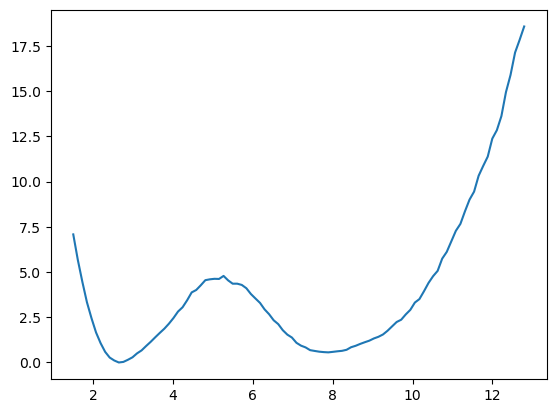

In [2]:
# Initialize analyzer
analyzer = FESAnalyzer('output.nc', './dRMStraj_nc_StateB.dat', interval=5)

# Perform parameter sweeps
params = {
    'g': 1,
    'length_ratio': 1.0,
    'start_point': None,
    'start_ratio': 0.2,
    'selected_state': 5
}

mixing_parameters ={
    'beta':1/175,
    'C1': -198,
    'C2':0
}

analyzer.initialize_fes(g=params['g'], length_ratio=params['length_ratio'],
                    start_point=params['start_point'], start_ratio=params['start_ratio'])
# results[value] = analyzer.analyze_onestate(selected_state=params['selected_state'], left_bound=35, right_bound=47)


results = analyzer.analyze_one_mixing_parameters(mixing_parameters=mixing_parameters, temperature=310, method='EXP', left_bound=3, right_bound=8)
results['mixing_parameters'] = mixing_parameters
results['temperature'] = 310
results['method'] = 'EXP'
print(results['metrics'])

os.makedirs('FitEnergy', exist_ok=True)
analyzer.save_results(results, './FitEnergy/FreeEnergy_EXP.pkl')
import matplotlib.pyplot as plt
plt.plot(results['cv_values'], results['pmf'])

Could not locate checkpoint subfile. This is okay for analysis if the solvent trajectory is not needed, but not for production simulation!


u_n: (704011,)
cv_n:  (704011,)
bin_edges:  1.44495 12.854249999999999 101
{'barrier_pos': np.float64(4.4684145), 'barrier': np.float64(5.576821485111717), 'basin1_pos': np.float64(2.3006475), 'basin2_pos': np.float64(7.891204499999999), 'basin1_pmf': np.float64(0.0), 'basin2_pmf': np.float64(1.9142730342137741), 'keq': np.float64(0.9130378254091077)}


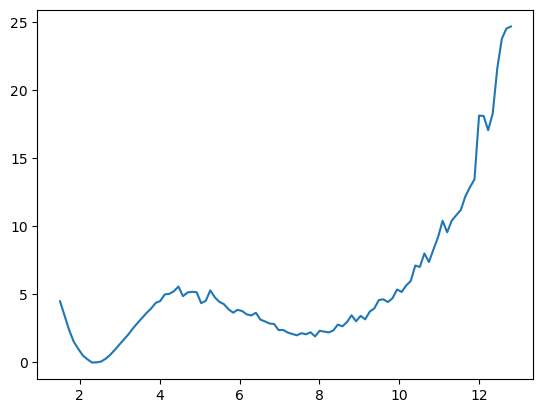

In [4]:
# Initialize analyzer
analyzer = FESAnalyzer('output.nc', './dRMStraj_nc_StateB.dat', interval=5)

# Perform parameter sweeps
params = {
    'g': 1,
    'length_ratio': 1.0,
    'start_point': None,
    'start_ratio': 0.2,
    'selected_state': 5
}

# mixing_parameters['delta'], mixing_parameters['C1'], mixing_parameters['C2']
mixing_parameters ={
    'delta': 116,
    'C1': -175,
    'C2':0
}

analyzer.initialize_fes(g=params['g'], length_ratio=params['length_ratio'],
                    start_point=params['start_point'], start_ratio=params['start_ratio'])
# results[value] = analyzer.analyze_onestate(selected_state=params['selected_state'], left_bound=35, right_bound=47)


results = analyzer.analyze_one_mixing_parameters(mixing_parameters=mixing_parameters, temperature=310, method='HAM', left_bound=3, right_bound=8)
results['mixing_parameters'] = mixing_parameters
results['temperature'] = 310
results['method'] = 'HAM'
print(results['metrics'])

os.makedirs('FitEnergy', exist_ok=True)
analyzer.save_results(results, './FitEnergy/FreeEnergy_HAM.pkl')
import matplotlib.pyplot as plt
plt.plot(results['cv_values'], results['pmf'])

In [ ]:
aaaa

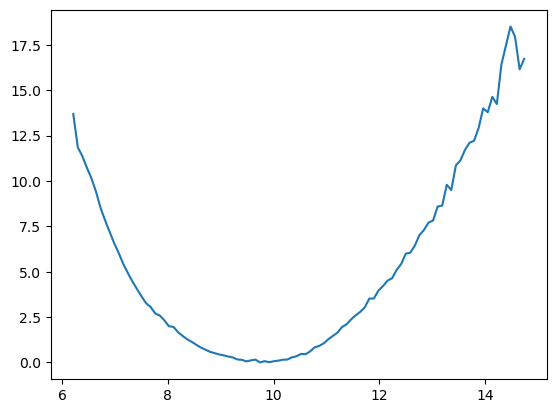

In [19]:
import matplotlib.pyplot as plt
results = state_results[0]
plt.plot(results['cv_values'], results['pmf'])

In [ ]:
    'beta': [1/200] * 11,
    'C1': np.linspace(-150, -350, 11),

(array([100.        , 113.33333333, 126.66666667, 140.        ,
        153.33333333, 166.66666667, 180.        , 193.33333333,
        206.66666667, 220.        , 233.33333333, 246.66666667,
        260.        , 273.33333333, 286.66666667, 300.        ,
        313.33333333, 326.66666667, 340.        , 353.33333333,
        366.66666667, 380.        , 393.33333333, 406.66666667,
        420.        , 433.33333333, 446.66666667, 460.        ,
        473.33333333, 486.66666667, 500.        ]),)

In [6]:
np.linspace(-150, -350, 11)[4:6]

array([-230., -250.])

Could not locate checkpoint subfile. This is okay for analysis if the solvent trajectory is not needed, but not for production simulation!

******* JAX 64-bit mode is now on! *******
*     JAX is now set to 64-bit mode!     *
*   This MAY cause problems with other   *
*      uses of JAX in the same code.     *
******************************************

ERROR:2025-11-23 17:40:22,718:jax._src.xla_bridge:473: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/ys/.conda/envs/ctgomartini_REMD2/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 201, in _version_check
    version = get_version()
              ^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:81: operation cusparseGetProperty(MAJOR_VERSION, &major) failed: The cuSPARSE library was not found.

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/home

u_n: (792011,)
cv_n:  (792011,)
bin_edges:  1.427375 12.547325 101
{'barrier_pos': np.float64(5.930954750000001), 'barrier': np.float64(2.7298911305742752), 'basin1_pos': np.float64(3.9293637500000003), 'basin2_pos': np.float64(7.82134625), 'basin1_pmf': np.float64(0.0), 'basin2_pmf': np.float64(1.4537672686602017), 'keq': np.float64(1.4106459057031155)}


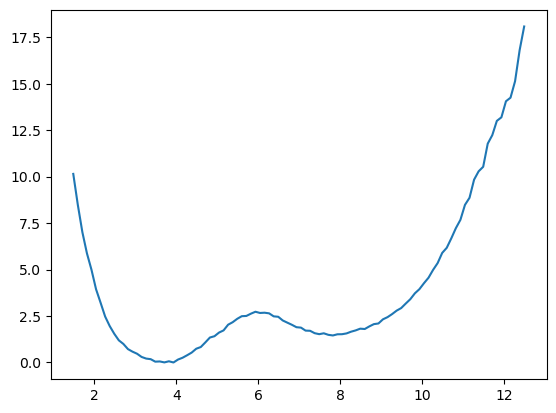

u_n: (792011,)
cv_n:  (792011,)
bin_edges:  1.427375 12.547325 101
{'barrier_pos': np.float64(5.930954750000001), 'barrier': np.float64(2.3332007957087626), 'basin1_pos': np.float64(3.9293637500000003), 'basin2_pos': np.float64(7.82134625), 'basin1_pmf': np.float64(0.0), 'basin2_pmf': np.float64(0.8402587345590052), 'keq': np.float64(1.1232550029283224)}


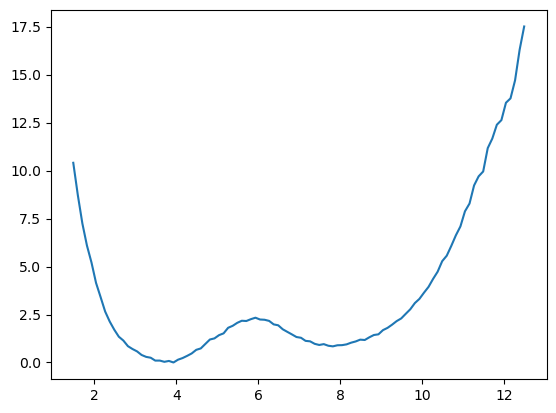

u_n: (792011,)
cv_n:  (792011,)
bin_edges:  1.427375 12.547325 101
{'barrier_pos': np.float64(5.930954750000001), 'barrier': np.float64(1.9250128060454532), 'basin1_pos': np.float64(3.9293637500000003), 'basin2_pos': np.float64(7.82134625), 'basin1_pmf': np.float64(0.0), 'basin2_pmf': np.float64(0.23199579126406045), 'keq': np.float64(0.8990847171074883)}


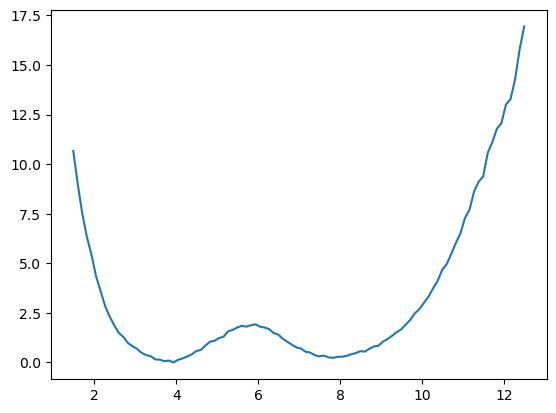

u_n: (792011,)
cv_n:  (792011,)
bin_edges:  1.427375 12.547325 101
{'barrier_pos': np.float64(5.930954750000001), 'barrier': np.float64(1.7867640821768318), 'basin1_pos': np.float64(3.9293637500000003), 'basin2_pos': np.float64(7.82134625), 'basin1_pmf': np.float64(0.06985620135470999), 'basin2_pmf': np.float64(0.0), 'keq': np.float64(0.8061933536224154)}


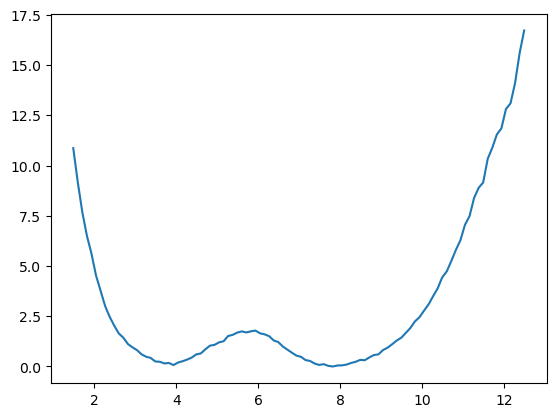

u_n: (792011,)
cv_n:  (792011,)
bin_edges:  1.427375 12.547325 101
{'barrier_pos': np.float64(5.48615675), 'barrier': np.float64(2.357523320208004), 'basin1_pos': np.float64(3.9293637500000003), 'basin2_pos': np.float64(7.82134625), 'basin1_pmf': np.float64(1.5515291120080987), 'basin2_pmf': np.float64(0.0), 'keq': np.float64(0.4006225323709802)}


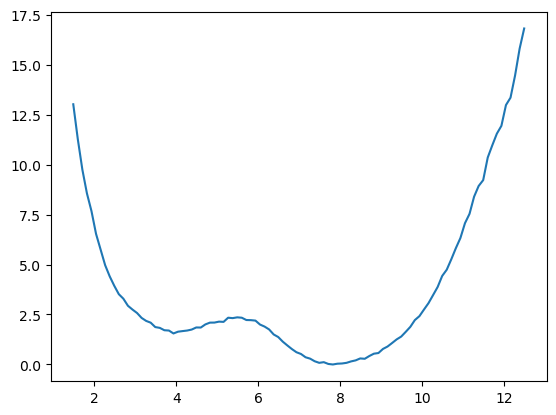

In [2]:
# Initialize analyzer
analyzer = FESAnalyzer('output.nc', './dRMStraj_nc_StateB.dat', interval=5)

# Perform parameter sweeps
params = {
    'g': 1,
    'length_ratio': 1.0,
    'start_point': None,
    'start_ratio': 0.1,
    'selected_state': 5
}

mixing_parameters ={
    'beta':1/200,
    'C1': -200,
    'C2':0
}

for C1 in [-240, -242, -244, -245, -250]:
    mixing_parameters['C1'] = C1

    analyzer.initialize_fes(g=params['g'], length_ratio=params['length_ratio'],
                        start_point=params['start_point'], start_ratio=params['start_ratio'])
    # results[value] = analyzer.analyze_onestate(selected_state=params['selected_state'], left_bound=35, right_bound=47)


    results = analyzer.analyze_one_mixing_parameters(mixing_parameters=mixing_parameters, temperature=310, method='EXP', left_bound=4, right_bound=8)
    print(results['metrics'])
    import matplotlib.pyplot as plt
    plt.plot(results['cv_values'], results['pmf'])
    plt.show()

In [ ]:
# Initialize analyzer
analyzer = FESAnalyzer('output.nc', './dRMStraj_nc_StateB.dat', interval=5)

# Perform parameter sweeps
params = {
    'g': 1,
    'length_ratio': 1.0,
    'start_point': None,
    'start_ratio': 0.1,
    'selected_state': 5
}

mixing_parameters ={
    'beta':1/200,
    'C1': -200,
    'C2':0
}

for C1 in [-240, -242, -244, -245, -250]:
    mixing_parameters['C1'] = C1

    analyzer.initialize_fes(g=params['g'], length_ratio=params['length_ratio'],
                        start_point=params['start_point'], start_ratio=params['start_ratio'])
    # results[value] = analyzer.analyze_onestate(selected_state=params['selected_state'], left_bound=35, right_bound=47)


    results = analyzer.analyze_one_mixing_parameters(mixing_parameters=mixing_parameters, temperature=310, method='EXP', left_bound=4, right_bound=8)
    print(results['metrics'])
    import matplotlib.pyplot as plt
    plt.plot(results['cv_values'], results['pmf'])
    plt.show()